# 11 - Train YAMNet Classifier

## Objective

Train a neural network classifier using the embeddings extracted from
Google's pretrained YAMNet model.

Pipeline

Audio
↓

YAMNet (Frozen)

↓

1024-dimensional Embeddings

↓

Dense Neural Network

↓

Prediction

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q joblib

In [3]:
import os
import joblib
import numpy as np
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight

In [4]:
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
EMBEDDING_FOLDER = "/content/drive/MyDrive/Underwater Audio Data/embeddings"

MODEL_FOLDER = "/content/drive/MyDrive/Underwater Audio Data/models"

os.makedirs(MODEL_FOLDER, exist_ok=True)

# Load Embeddings

In [6]:
X_train = np.load(os.path.join(EMBEDDING_FOLDER,"train_embeddings.npy"))

y_train = np.load(os.path.join(EMBEDDING_FOLDER,"train_labels.npy"))

X_val = np.load(os.path.join(EMBEDDING_FOLDER,"validation_embeddings.npy"))

y_val = np.load(os.path.join(EMBEDDING_FOLDER,"validation_labels.npy"))

X_test = np.load(os.path.join(EMBEDDING_FOLDER,"test_embeddings.npy"))

y_test = np.load(os.path.join(EMBEDDING_FOLDER,"test_labels.npy"))

In [7]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(3915, 1024)
(406, 1024)
(596, 1024)


In [8]:
encoder = joblib.load(
    os.path.join(
        EMBEDDING_FOLDER,
        "label_encoder.pkl"
    )
)

print(encoder.classes_)

['Ambience' 'Biological' 'Vessels']


# Compute Class Weights

In [9]:
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(6.098130841121495), np.int64(1): np.float64(2.9260089686098656), np.int64(2): np.float64(0.4009216589861751)}


# Build Neural Network

In [10]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(1024,)),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dense(
        512,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.40),

    tf.keras.layers.Dense(
        256,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.30),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        len(encoder.classes_),
        activation="softmax"
    )

])

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,507 (2.65 MB)

 Trainable params: 691,459 (2.64 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [12]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]

)

# Callbacks

In [13]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(

        monitor="val_loss",

        patience=8,

        restore_best_weights=True

    ),

    tf.keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=3,

        verbose=1

    ),

    tf.keras.callbacks.ModelCheckpoint(

        filepath=os.path.join(
            MODEL_FOLDER,
            "yamnet_classifier.keras"
        ),

        save_best_only=True,

        monitor="val_loss"

    )

]

# Train Model

In [17]:
history = model.fit(

    X_train,

    y_train,

    validation_data=(

        X_val,

        y_val

    ),

    epochs=50,

    batch_size=32,

    class_weight=class_weights,

    callbacks=callbacks,

    verbose=1

)

Epoch 1/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9895 - loss: 0.5039 - val_accuracy: 0.8744 - val_loss: 0.3746 - learning_rate: 0.0010
Epoch 2/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9837 - loss: 0.3385 - val_accuracy: 0.8498 - val_loss: 0.9117 - learning_rate: 0.0010
Epoch 3/50
120/123 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9917 - loss: 0.4841
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9934 - loss: 0.3656 - val_accuracy: 0.8768 - val_loss: 0.6566 - learning_rate: 0.0010
Epoch 4/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9944 - loss: 0.1615 - val_accuracy: 0.8818 - val_loss: 0.5190 - learning_rate: 5.0000e-04
Epoch 5/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9969 - loss: 0.1002 - val_accuracy: 0.9113 - val_loss: 0.3152 - learning_rate: 5.0000e-04
Epoch 6/50
121/123 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9959 - l

# Training Curves

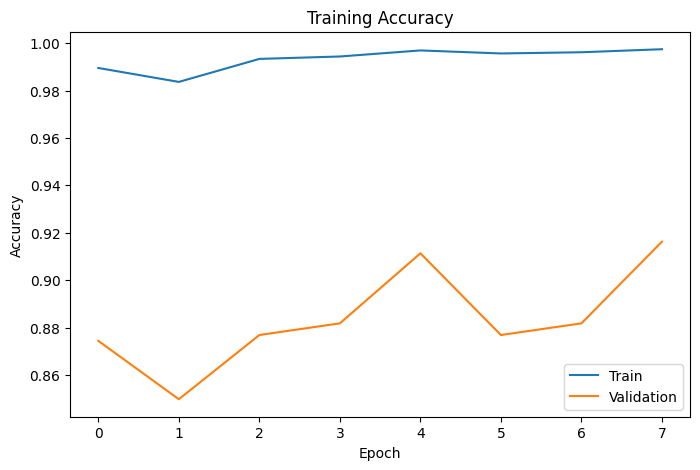

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"],label="Train")

plt.plot(history.history["val_accuracy"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.legend()

plt.show()

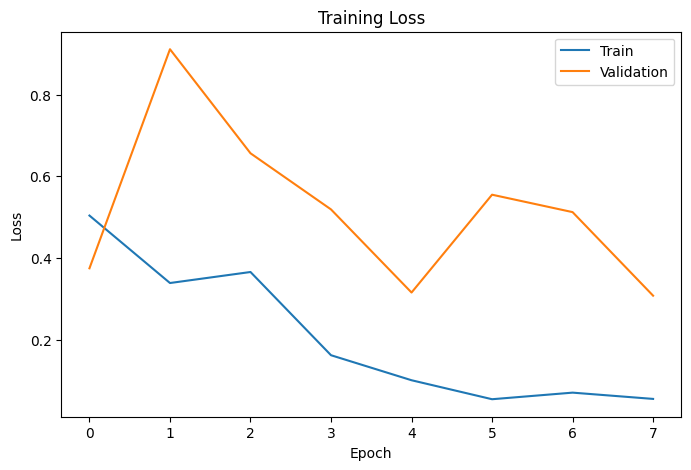

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"],label="Train")

plt.plot(history.history["val_loss"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.legend()

plt.show()

In [20]:
test_loss, test_accuracy = model.evaluate(

    X_test,

    y_test,

    verbose=0

)

print(f"Test Accuracy : {test_accuracy:.4f}")

print(f"Test Loss     : {test_loss:.4f}")

Test Accuracy : 0.9480
Test Loss     : 0.1755


In [21]:
from sklearn.metrics import classification_report, accuracy_score

# Make predictions on the test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert numerical labels to original class names for a more readable report
y_test_decoded = encoder.inverse_transform(y_test)
y_pred_decoded = encoder.inverse_transform(y_pred)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test_decoded, y_pred_decoded, target_names=encoder.classes_))

# Print overall accuracy (though already calculated by model.evaluate, this confirms consistency)
accuracy = accuracy_score(y_test_decoded, y_pred_decoded)
print(f"\nOverall Accuracy: {accuracy:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Classification Report:
              precision    recall  f1-score   support

    Ambience       0.90      0.97      0.93        58
  Biological       0.76      0.66      0.70        56
     Vessels       0.97      0.98      0.98       482

    accuracy                           0.95       596
   macro avg       0.88      0.87      0.87       596
weighted avg       0.95      0.95      0.95       596


Overall Accuracy: 0.9480


In [ ]:
model.save(

    os.path.join(

        MODEL_FOLDER,

        "yamnet_classifier_final.keras"

    )

)

print("Model saved successfully.")

In [22]:
print(f"Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.9974
Validation Accuracy: 0.9163
Test Accuracy: 0.9480
